## Preliminaries

In [1]:
import pandas as pd
import numpy as np

In [2]:
# =========================================================
# LOAD PREDICTIONS
# =========================================================

predictions = pd.read_csv("predictions/fdata/predictions_s.csv")

In [3]:
def load_swf(filepath, sim_start_time):
    df = pd.read_csv(filepath, sep=';')

    # Convert timestamps to seconds from simulation start
    df["start_time"] = pd.to_datetime(df["start_time"]).astype("int64") // 10**9
    df["end_time"] = pd.to_datetime(df["end_time"]).astype("int64") // 10**9

    df["start_time"] -= sim_start_time
    df["end_time"] -= sim_start_time

    diff = min(df["start_time"])
    
    df["end_time"] -= diff
    df["start_time"] -= diff
    
    return df

In [4]:
TOTAL_NODES = 158976

def node_utilization(df):

    # ----------------------------------------
    # Preprocessing
    # ----------------------------------------
    df = df.sort_values("start_time").copy()

    # ----------------------------------------
    # UTILIZATION EVENTS
    # ----------------------------------------
    events = []  # (time, delta_nodes)

    for _, row in df.iterrows():
        events.append((row["start_time"], +row["nodes"]))
        events.append((row["end_time"], -row["nodes"]))

    # ----------------------------------------
    # NODE UTILIZATION (event sweep)
    # ----------------------------------------
    events.sort(key=lambda x: x[0])

    times = []
    utilizations = []

    cores = TOTAL_NODES
    
    current_nodes = 0
    last_time = None

    for time, delta in events:

        if last_time is not None and time != last_time:
            # Record utilization for previous interval
            utilization = current_nodes / cores
            times.append(last_time)
            utilizations.append(utilization)

        current_nodes += delta
        last_time = time

    # Add final point
    if last_time is not None:
        times.append(last_time)
        utilizations.append(current_nodes / cores)

    return {
        "time": np.array(times),
        "node_utilization": np.array(utilizations)
    }

def queue_size_over_time(df):
    df = df.copy()

    events = []  # (time, delta_queue)

    # ----------------------------------------
    # Real queue events
    # ----------------------------------------
    for _, row in df.iterrows():
        if row["wtime"] > 0:
            events.append((row["submit_time"], +1))
            events.append((row["start_time"], -1))

    # ----------------------------------------
    # Boundary conditions
    # ----------------------------------------
    t_start = df["submit_time"].min()
    t_end = df["end_time"].max()

    # Add dummy events to enforce boundaries
    events.append((t_start, 0))
    events.append((t_end, 0))

    # ----------------------------------------
    # Sort events
    # ----------------------------------------
    events.sort(key=lambda x: x[0])

    times = []
    queue_sizes = []

    current_queue = 0
    last_time = None

    # ----------------------------------------
    # Event sweep
    # ----------------------------------------
    for time, delta in events:
        if last_time is not None and time != last_time:
            times.append(last_time)
            queue_sizes.append(current_queue)

        current_queue += delta
        last_time = time

    # Add final point
    if last_time is not None:
        times.append(last_time)
        queue_sizes.append(current_queue)

    return {
        "time": np.array(times),
        "queue_size": np.array(queue_sizes)
    }

In [5]:
import matplotlib.pyplot as plt

def plot_utilization(sim_result, title="Node Utilization"):
    plt.figure(figsize=(10, 5))
    
    plt.plot(sim_result["time"]/max(sim_result["time"])*100, sim_result["node_utilization"]*100)
    
    plt.xlabel("Makespan (%)")
    plt.ylabel("Utilization (%)")
    plt.title(title)
    
    plt.grid()
    plt.show()

def plot_queue(sim_result, title="Queue Size"):
    plt.figure(figsize=(10, 5))
    
    plt.plot(sim_result["time"]/max(sim_result["time"])*100, sim_result["queue_size"])
    
    plt.xlabel("Makespan (%)")
    plt.ylabel("Queue Size")
    plt.title(title)
    
    plt.grid()
    plt.show()

def plot_utilization_with_queue_bands(util_result, queue_result, title="Utilization vs Queue", image_path=""):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Normalize time (based on utilization timeline)
    t_util = util_result["time"] / max(util_result["time"]) * 100
    t_queue = queue_result["time"] / max(util_result["time"]) * 100

    util = util_result["node_utilization"] * 100
    queue = queue_result["queue_size"]

    # ----------------------------------------
    # Background bands (queue state)
    # ----------------------------------------
    for i in range(len(t_queue) - 1):
        t_start = t_queue[i]
        t_end = t_queue[i + 1]

        if queue[i] > 0:
            color = "red"
            alpha = 0.15
        else:
            color = "green"
            alpha = 0.1

        ax.axvspan(t_start, t_end, color=color, alpha=alpha)

    # ----------------------------------------
    # Utilization line (BLACK as requested)
    # ----------------------------------------
    ax.plot(t_util, util, linewidth=2, label="Utilization (%)")

    # ----------------------------------------
    # Labels & styling
    # ----------------------------------------
    ax.set_xlabel("Makespan (%)")
    ax.set_ylabel("Utilization (%)")
    ax.set_ylim(0, 100)
    ax.set_title(title)

    ax.grid(True)

    # Custom legend (since bands don't auto-legend well)
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.1, label='Queue = 0'),
        Patch(facecolor='red', alpha=0.15, label='Queue > 0'),
    ]

    line = ax.get_lines()[0]
    ax.legend(handles=legend_elements, loc="upper right")
    
    plt.tight_layout()
    # Salvataggio opzionale
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")
    
    plt.show()

def plot_utilization_all(util_list, labels, title="Node Utilization", image_path=""):
    plt.figure(figsize=(10, 5))
    
    for sim_result, label in zip(util_list, labels):
        plt.plot(
            sim_result["time"]/max(sim_result["time"])*100,
            sim_result["node_utilization"]*100,
            label=label
        )
    
    plt.xlabel("Makespan (%)")
    plt.ylabel("Utilization (%)")
    plt.title(title)
    
    plt.legend()
    plt.grid()

    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")
    
    plt.show()

## Heavy

In [6]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/fdata/fdata_18k_1.swf',
    header=None,
    sep='\t'
)

workload_column_names = [
    "Job Number", "Submit Time", "Wait Time", "Run Time",
    "Number of Allocated Nodes", "Average CPU Time Used",
    "Used Memory", "Requested Number of Nodes",
    "Requested Time", "Requested Memory", "Status",
    "User ID", "Group ID", "Executable Number",
    "Queue Number", "Partition Number",
    "Preceding Job Number", "Think Time from Preceding Job"
]

workload_df.columns = workload_column_names

# Rename for consistency
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})

### SJF

In [7]:
# =========================================================
# LOAD EXECUTION ORDER AND MERGE WITH WORKLOAD
# =========================================================

column_names = ['n', 'job_id', 'submit_time', 'start_time', 'end_time', 'wtime', 'rtime', 'slowdown', 'nodes']

sim_start_time = 1600210177
filepath = 'queues/fdata/18000x158976/heavy_1/fdata_18k_1_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

# Merge runtime info
df = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)

df = df.sort_values("start_time").reset_index(drop=True)
df = df[column_names]

In [8]:
util_heavy_sjf = node_utilization(df)

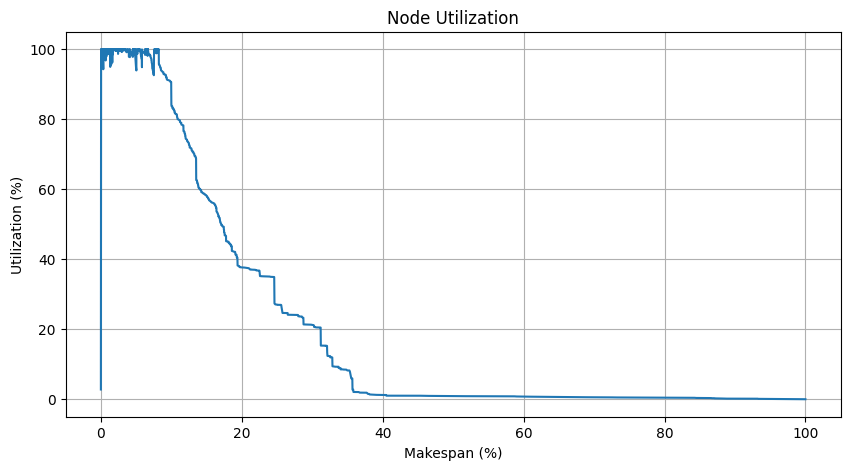

In [9]:
plot_utilization(util_heavy_sjf)

In [10]:
queue_heavy_sjf = queue_size_over_time(df)

Grafico salvato in: images/18000x158976/util_vs_queue_F2.png


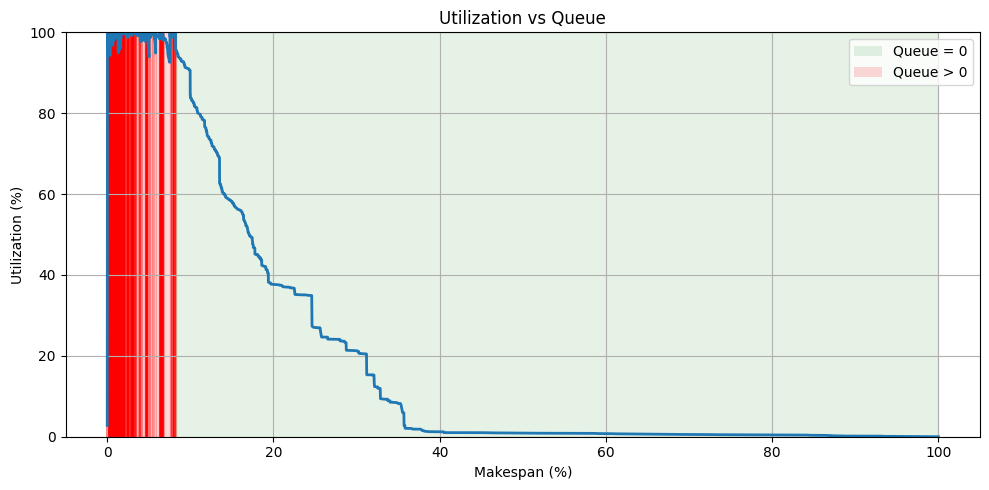

In [11]:
plot_utilization_with_queue_bands(util_heavy_sjf, queue_heavy_sjf, image_path="images/18000x158976/util_vs_queue_F2.png")

## Normal

In [12]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/fdata/fdata.swf',
    header=None,
    sep='\t'
)

workload_column_names = [
    "Job Number", "Submit Time", "Wait Time", "Run Time",
    "Number of Allocated Nodes", "Average CPU Time Used",
    "Used Memo§ry", "Requested Number of Nodes",
    "Requested Time", "Requested Memory", "Status",
    "User ID", "Group ID", "Executable Number",
    "Queue Number", "Partition Number",
    "Preceding Job Number", "Think Time from Preceding Job"
]

workload_df.columns = workload_column_names

# Rename for consistency
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})

### SJF

In [24]:
# =========================================================
# LOAD EXECUTION ORDER AND MERGE WITH WORKLOAD
# =========================================================

column_names = ['n', 'job_id', 'submit_time', 'start_time', 'end_time', 'wtime', 'rtime', 'slowdown', 'nodes']

sim_start_time = 1600210177
filepath = 'queues/fdata/74000x158976/fdata_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

# Merge runtime info
df = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)

df = df.sort_values("start_time").reset_index(drop=True)
df = df[column_names]

In [25]:
util_normal_sjf = node_utilization(df)

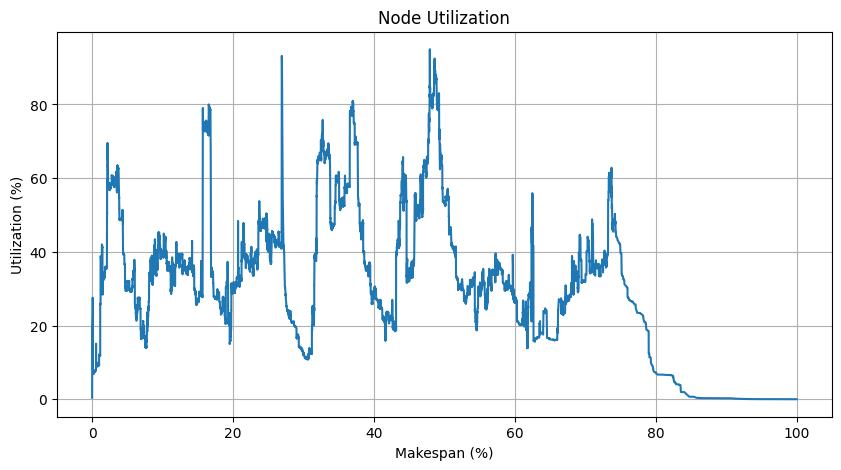

In [26]:
plot_utilization(util_normal_sjf)

In [27]:
queue_normal_sjf = queue_size_over_time(df)

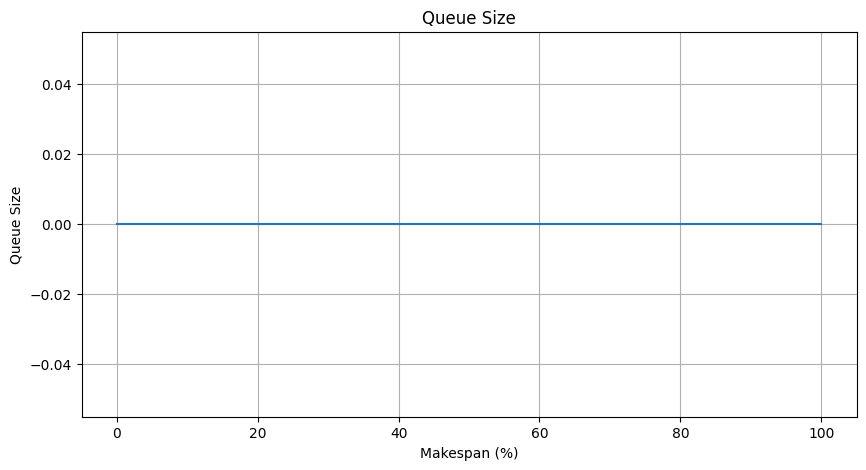

In [28]:
plot_queue(queue_normal_sjf)

Grafico salvato in: images/74000x158976/util_vs_queue_F1.png


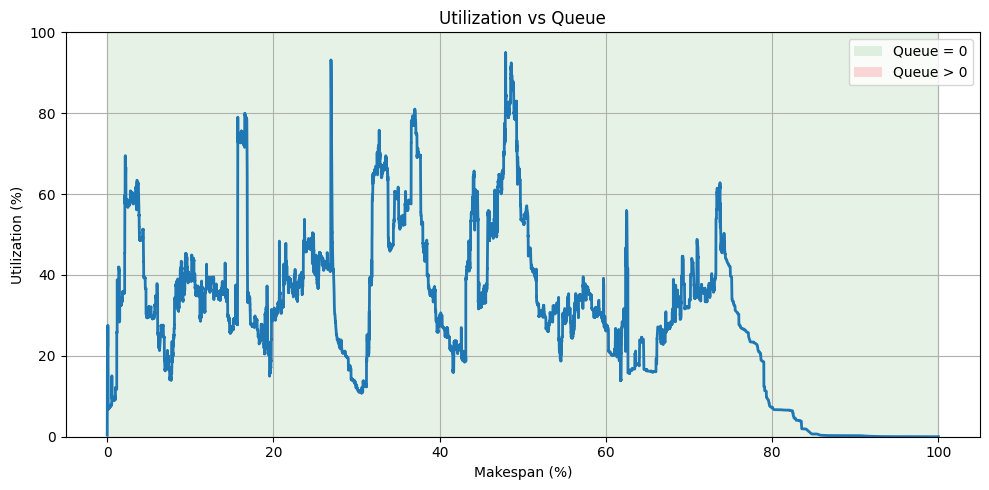

In [29]:
plot_utilization_with_queue_bands(util_normal_sjf, queue_normal_sjf, image_path="images/74000x158976/util_vs_queue_F1.png")

In [30]:
len(df[df["wtime"] > 0])

0

In [31]:
len(df[df["wtime"] > 5])

0

## Combined Plot

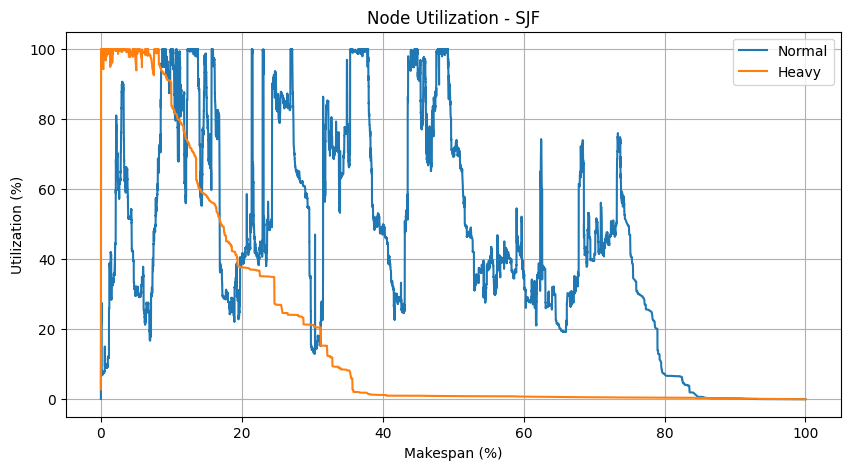

In [21]:
results = [
    util_normal_sjf,
    util_heavy_sjf
]

labels = [
    "Normal",
    "Heavy"
]

plot_utilization_all(results, labels,  title="Node Utilization - SJF")

## Average and Peak Node Utilization

In [22]:
print("Normal - SJF =", np.mean(util_normal_sjf['node_utilization']))
print("Heavy - SJF  =", np.mean(util_heavy_sjf['node_utilization']))

Normal - SJF = 0.6048520811772188
Heavy - SJF  = 0.8782460851691724


In [23]:
print("Normal - SJF =", max(util_normal_sjf['node_utilization']))
print("Heavy - SJF  =", max(util_heavy_sjf['node_utilization']))

Normal - SJF = 1.0
Heavy - SJF  = 1.0
